# Direct Modulator

## Sample 0 - good

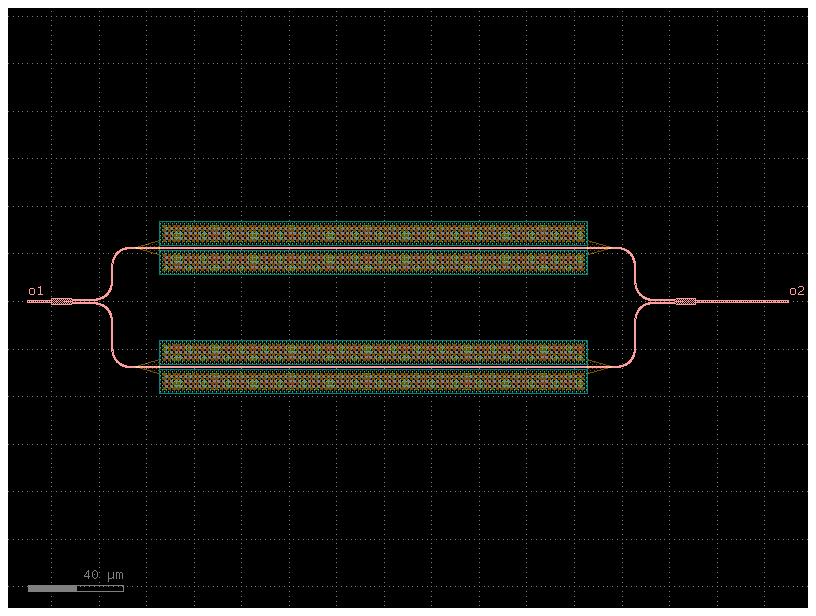

In [17]:
import gdsfactory as gf

circuit = gf.Component()

mzm = circuit.add_ref(gf.components.mzm(delta_length=10, length_y=2, length_x=200, bend='bend_euler', straight='straight'))
mzm.move((0, 0))

straight_waveguide = circuit.add_ref(gf.components.straight(length=10))
straight_waveguide.move((300, 0))

route1 = gf.routing.route_single(
    circuit,
    port1=mzm.ports['o2'],
    port2=straight_waveguide.ports['o1'],
    cross_section='strip',
    radius=5,
)

circuit.add_port('o1', port=mzm.ports['o1'])
circuit.add_port('o2', port=straight_waveguide.ports['o2'])

circuit.draw_ports()
circuit.plot()

# Direct Modulator

## Sample 1 - func

In [18]:
import gdsfactory as gf

c = gf.Component()

mzm = c.add_ref(gf.components.mzm(delta_length=10, length_y=2, length_x=200))

straight = c.add_ref(gf.components.straight(length=50))

straight.move((0, 50))

route1 = gf.routing.route_single(
    c, port1=mzm.ports['o3'], port2=straight.ports['o1'], cross_section='strip', radius=5
)

c.add_port('o1', port=mzm.ports['o1'])
c.add_port('o2', port=straight.ports['o2'])

c.plot()

KeyError: "key='o3' is not a valid port name or index. Make sure the instance is an array when giving it a tuple. Available ports: ['o1', 'o2', 'e3', 'e6', 'e10', 'e15', 'e4', 'e5', 'e9', 'e16', 'e1', 'e8', 'e12', 'e13', 'e2', 'e7', 'e11', 'e14']"

# Direct Modulator

## Sample 2 - good

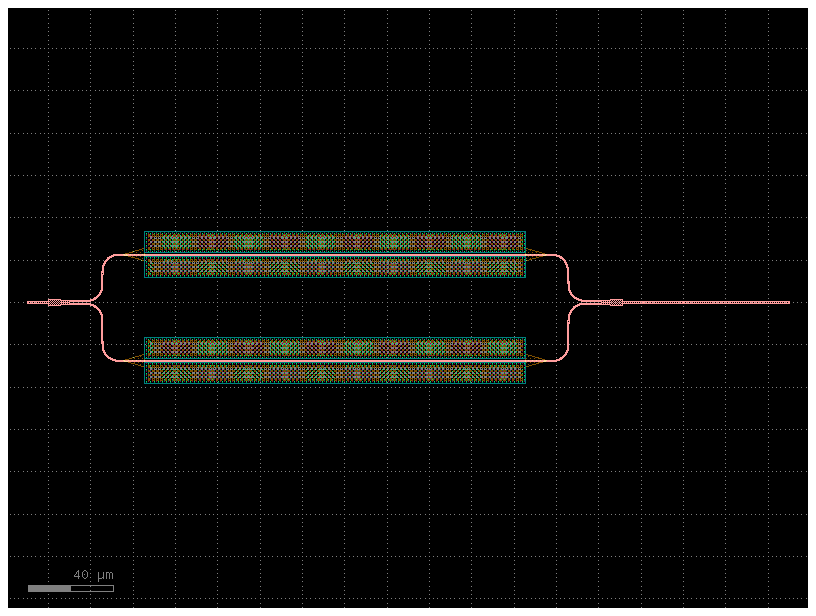

In [19]:
import gdsfactory as gf

c = gf.Component()

mzm = c.add_ref(
    gf.components.mzm(
        delta_length=10, 
        length_y=2, 
        length_x=200, 
        bend='bend_euler', 
        straight='straight',
        splitter='mmi1x2', 
        combiner=None, 
        with_splitter=True, 
        port_e1_splitter='o2', 
        port_e0_splitter='o3', 
        port_e1_combiner='o2', 
        port_e0_combiner='o3'
    )
)
mzm.move((0, 0))

straight = c.add_ref(gf.components.straight(length=50))
straight.move((300, 0))

route = gf.routing.route_single(
    c,
    port1=mzm.ports['o2'],
    port2=straight.ports['o1'],
    cross_section='strip',
    radius=5
)

c.add_port('o1', port=mzm.ports['o1'])
c.add_port('o2', port=straight.ports['o2'])

c.plot()

# 8-QAM Modulator

## Sample 0 - func

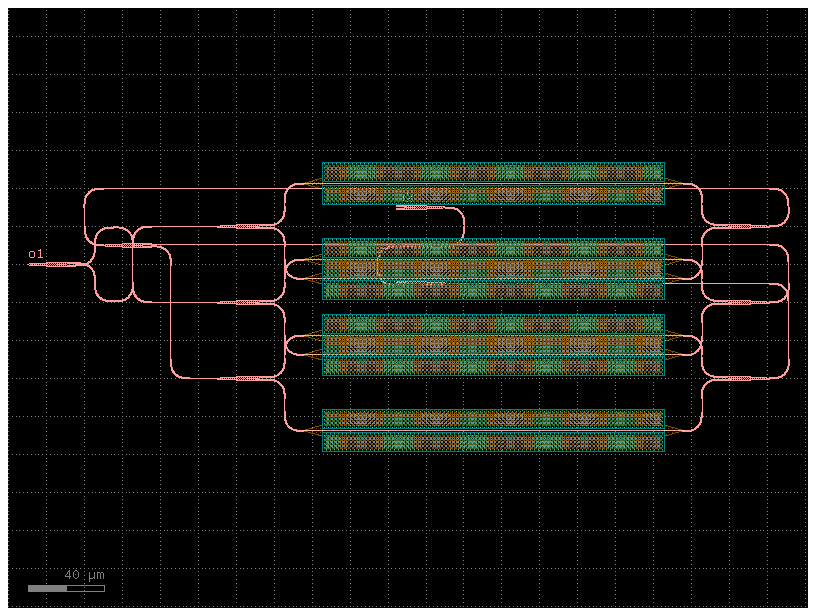

In [20]:
import gdsfactory as gf

circuit = gf.Component()

splitter1 = circuit.add_ref(gf.components.mmi1x2())
splitter1.move((0, 0))

splitter2 = circuit.add_ref(gf.components.mmi1x2())
splitter2.move((40, 10))

mzm_bit1 = circuit.add_ref(gf.components.mzm())
mzm_bit1.move((100, 20))

mzm_bit2 = circuit.add_ref(gf.components.mzm())
mzm_bit2.move((100, -20))

mzm_bit3 = circuit.add_ref(gf.components.mzm())
mzm_bit3.move((100, -60))

combiner1 = circuit.add_ref(gf.components.mmi1x2())
combiner1.rotate(180)
combiner1.move((200, -10))

combiner2 = circuit.add_ref(gf.components.mmi1x2())
combiner2.rotate(180)
combiner2.move((200, 30))

route1 = gf.routing.route_single(circuit, port1=splitter1.ports['o2'], port2=mzm_bit1.ports['o1'], cross_section='strip')
route2 = gf.routing.route_single(circuit, port1=splitter1.ports['o3'], port2=mzm_bit2.ports['o1'], cross_section='strip')
route3 = gf.routing.route_single(circuit, port1=mzm_bit1.ports['o2'], port2=splitter2.ports['o1'], cross_section='strip')
route4 = gf.routing.route_single(circuit, port1=mzm_bit2.ports['o2'], port2=splitter2.ports['o2'], cross_section='strip')

route5 = gf.routing.route_single(circuit, port1=splitter2.ports['o3'], port2=mzm_bit3.ports['o1'], cross_section='strip')
route6 = gf.routing.route_single(circuit, port1=mzm_bit3.ports['o2'], port2=combiner1.ports['o1'], cross_section='strip')

route7 = gf.routing.route_single(circuit, port1=combiner1.ports['o2'], port2=combiner2.ports['o1'], cross_section='strip')

circuit.add_port('o1', port=splitter1.ports['o1'])
circuit.add_port('o2', port=combiner2.ports['o2'])

circuit.draw_ports()
circuit.plot()

# 8-QAM Modulator

## Sample 1 - func

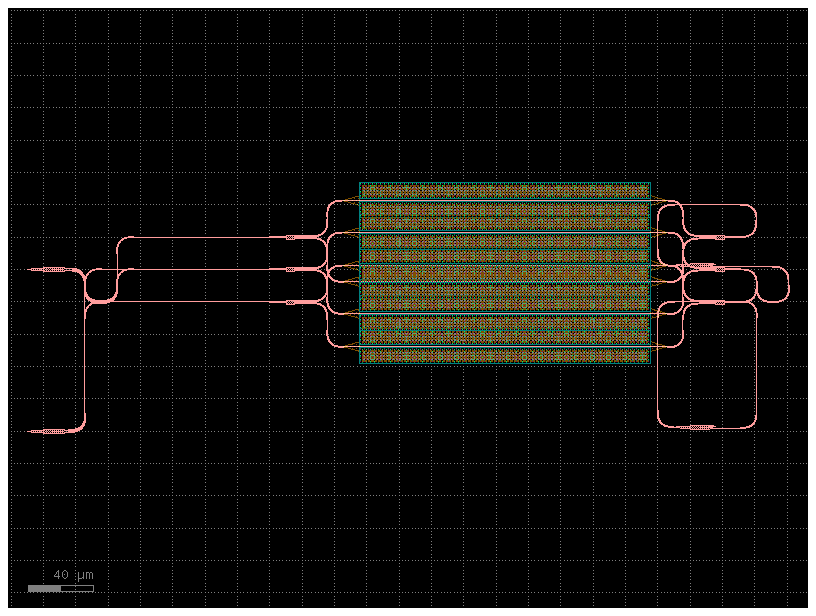

In [21]:
import gdsfactory as gf

c = gf.Component()

# Instantiate components
splitter1 = c.add_ref(gf.components.mmi1x2())
splitter2 = c.add_ref(gf.components.mmi1x2())

combiner1 = c.add_ref(gf.components.mmi1x2())
combiner1.mirror(p1=(1, 0), p2=(0, 0))

combiner2 = c.add_ref(gf.components.mmi1x2())
combiner2.mirror(p1=(1, 0), p2=(0, 0))

mzm_bit1 = c.add_ref(gf.components.mzm(delta_length=10, length_y=2, length_x=200))
mzm_bit2 = c.add_ref(gf.components.mzm(delta_length=10, length_y=2, length_x=200))
mzm_bit3 = c.add_ref(gf.components.mzm(delta_length=10, length_y=2, length_x=200))

# Move components to appropriate positions
splitter1.move((0, 0))
splitter2.move((0, -100))

combiner1.move((400, 0))
combiner2.move((400, -100))

mzm_bit1.move((150, 20))
mzm_bit2.move((150, 0))
mzm_bit3.move((150, -20))

# Connect ports with route_single
gf.routing.route_single(c, splitter1.ports['o2'], mzm_bit1.ports['o1'], cross_section='strip')
gf.routing.route_single(c, splitter1.ports['o3'], mzm_bit2.ports['o1'], cross_section='strip')

gf.routing.route_single(c, splitter2.ports['o2'], mzm_bit2.ports['o1'], cross_section='strip')
gf.routing.route_single(c, splitter2.ports['o3'], mzm_bit3.ports['o1'], cross_section='strip')

gf.routing.route_single(c, mzm_bit1.ports['o2'], combiner1.ports['o1'], cross_section='strip')
gf.routing.route_single(c, mzm_bit2.ports['o2'], combiner1.ports['o2'], cross_section='strip')

gf.routing.route_single(c, mzm_bit2.ports['o2'], combiner2.ports['o1'], cross_section='strip')
gf.routing.route_single(c, mzm_bit3.ports['o2'], combiner2.ports['o2'], cross_section='strip')

# Expose external ports
c.add_port('o1', port=splitter1.ports['o1'])
c.add_port('o2', port=combiner1.ports['o3'])
c.add_port('o3', port=combiner2.ports['o3'])

c.plot()

# 8-QAM Modulator

## Sample 2 - func

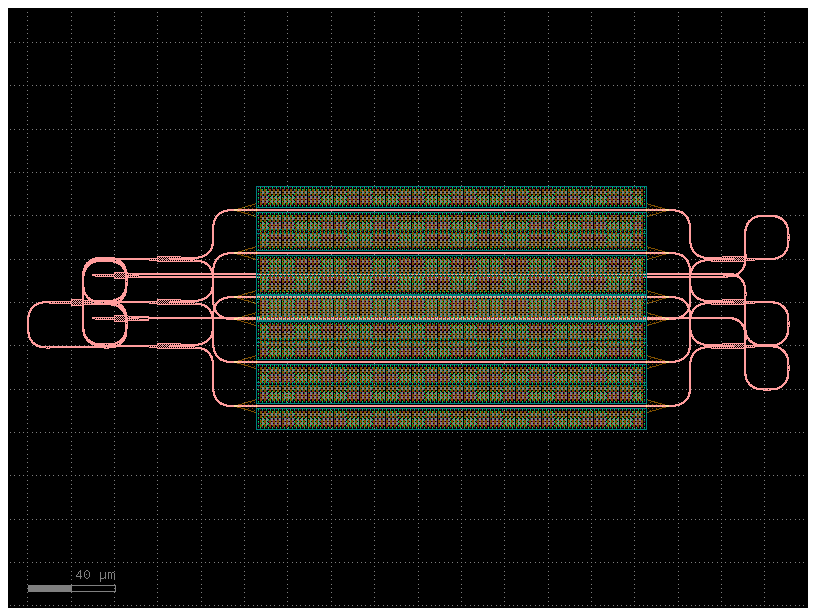

In [5]:
import gdsfactory as gf

c = gf.Component()

splitter1 = c << gf.components.mmi1x2()
splitter1.move((40, 0))

splitter2 = c << gf.components.mmi1x2()
splitter2.move((40, 0))

mzm_bit1 = c << gf.components.mzm()
mzm_bit2 = c << gf.components.mzm()
mzm_bit3 = c << gf.components.mzm()

mzm_bit1.move((80, 20))
mzm_bit2.move((80, 0))
mzm_bit3.move((80, -20))

combiner1 = c << gf.components.mmi1x2()
combiner1.mirror((1, 0))
combiner1.move((60, 10))

combiner2 = c << gf.components.mmi1x2()
combiner2.mirror((1, 0))
combiner2.move((60, -10))

gf.routing.route_single(c, splitter1.ports['o2'], mzm_bit1.ports['o1'], cross_section='strip')
gf.routing.route_single(c, splitter1.ports['o3'], splitter2.ports['o1'], cross_section='strip')

gf.routing.route_single(c, splitter2.ports['o2'], mzm_bit2.ports['o1'], cross_section='strip')
gf.routing.route_single(c, splitter2.ports['o3'], mzm_bit3.ports['o1'], cross_section='strip')

gf.routing.route_single(c, mzm_bit1.ports['o2'], combiner1.ports['o2'], cross_section='strip')
gf.routing.route_single(c, mzm_bit2.ports['o2'], combiner1.ports['o3'], cross_section='strip')

gf.routing.route_single(c, mzm_bit3.ports['o2'], combiner2.ports['o3'], cross_section='strip')

c.add_port('o1', port=splitter1.ports['o1'])
c.add_port('o2', port=combiner1.ports['o1'])
c.add_port('o3', port=combiner2.ports['o1'])

c.plot()

# Mach-Zehnder interferometer

## Sample 0 - func

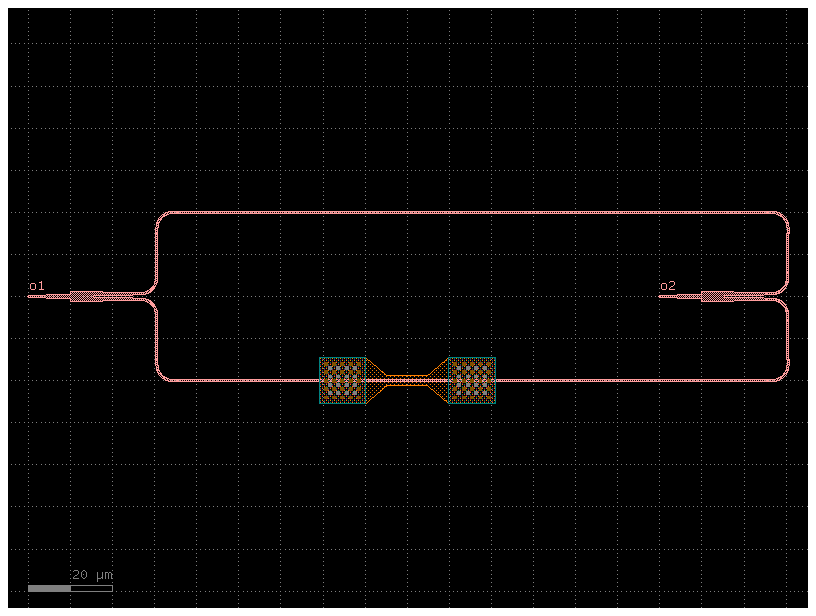

In [23]:
import gdsfactory as gf

circuit = gf.Component()

mmi1 = circuit.add_ref(gf.components.mmi1x2())
mmi2 = circuit.add_ref(gf.components.mmi1x2())
mmi2.move((150, 0))

waveguide = circuit.add_ref(gf.components.straight(length=10))
waveguide.move((75, 20))

phase_shifter = circuit.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter.move((75, -20))

route1 = gf.routing.route_single(
    circuit,
    port1=mmi1.ports['o2'],
    port2=waveguide.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    circuit,
    port1=mmi1.ports['o3'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)

route3 = gf.routing.route_single(
    circuit,
    port1=mmi2.ports['o2'],
    port2=waveguide.ports['o2'],
    cross_section='strip',
    radius=5,
)

route4 = gf.routing.route_single(
    circuit,
    port1=mmi2.ports['o3'],
    port2=phase_shifter.ports['o2'],
    cross_section='strip',
    radius=5,
)

circuit.add_port('o1', port=mmi1.ports['o1'])
circuit.add_port('o2', port=mmi2.ports['o1'])

circuit.draw_ports()
circuit.plot()

# Mach-Zehnder interferometer

## Sample 1 - func

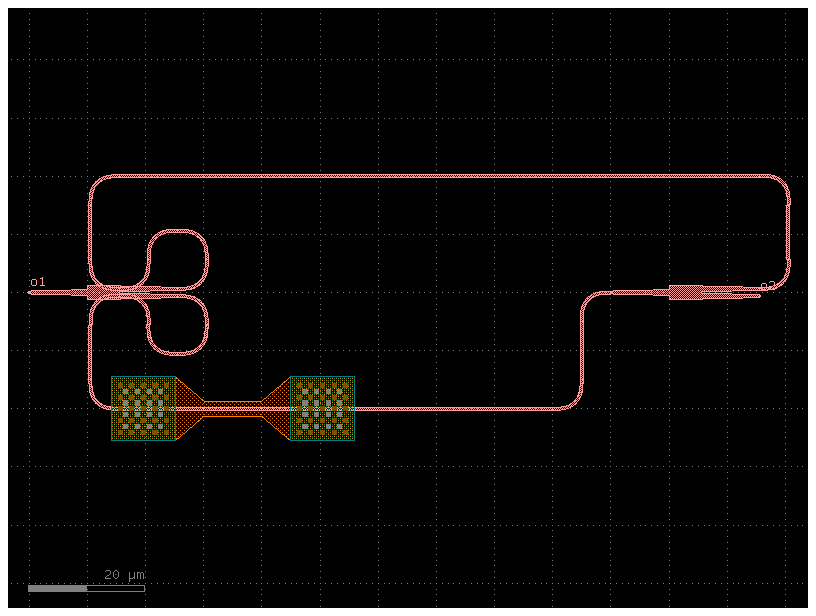

In [24]:
import gdsfactory as gf


c = gf.Component()


mmi1 = c << gf.components.mmi1x2()
mmi2 = c << gf.components.mmi1x2()


waveguide = c << gf.components.straight(length=10)
phase_shifter = c << gf.components.straight_heater_metal(length=10)


mmi2.move((100, 0))
waveguide.move((20, 20))
phase_shifter.move((20, -20))


route1 = gf.routing.route_single(
    c,
    port1=mmi1.ports['o2'],
    port2=waveguide.ports['o1'],
    cross_section='strip',
    radius=5,
)


route2 = gf.routing.route_single(
    c,
    port1=mmi1.ports['o3'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)


route3 = gf.routing.route_single(
    c,
    port1=mmi2.ports['o2'],
    port2=waveguide.ports['o2'],
    cross_section='strip',
    radius=5,
)


route4 = gf.routing.route_single(
    c,
    port1=mmi2.ports['o1'],
    port2=phase_shifter.ports['o2'],
    cross_section='strip',
    radius=5,
)


c.add_port('o1', port=mmi1.ports['o1'])
c.add_port('o2', port=mmi2.ports['o3'])


c.draw_ports()
c.plot()

# Mach-Zehnder interferometer

## Sample 2 - syntax

In [25]:
import gdsfactory as gf

r = gf.Component()

mmi1 = r.add_ref(gf.components.mmi1x2())
mmi1.move((0,0))

mmi2 = r.add_ref(gf.components.mmi1x2())
mmi2.move((150, 0))

waveguide = r.add_ref(gf.components.straight(length=10))
waveguide.connect(port='o1', destination=mmi1.ports['o3'])

phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter.move((50, 20))

route1 = gf.routing.route_single(
    r,
    port1=mmi1.ports['o2'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    r,
    port1=phase_shifter.ports['o2'],
    port2=mmi2.ports['o2'],
    cross_section='strip',
    radius=5,
)

route3 = gf.routing.route_single(
    r,
    port1=waveguide.ports['o2'],
    port2=mmi2.ports['o3'],
    cross_section='strip',
    radius=5,
)

r.add_port('o1', port=mmi1.ports['o1'])
r.add_port('o2', port=mmi2.ports['o1'])

r.draw_ports()
r.plot()

TypeError: ProtoTInstance.connect() got an unexpected keyword argument 'destination'

# Mach-Zehnder Modulator

## Sample 0 - func

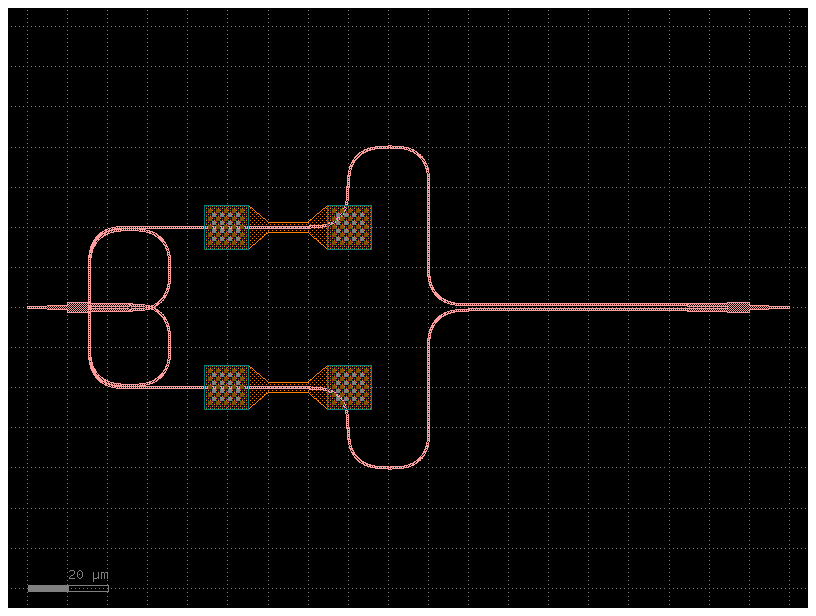

In [26]:
import gdsfactory as gf

c = gf.Component()

splitter = c << gf.components.mmi1x2()
combiner = c << gf.components.mmi1x2()

combiner.mirror()
combiner.move((150, 0))

phase_shifter1 = c << gf.components.straight_heater_metal(length=10)
phase_shifter2 = c << gf.components.straight_heater_metal(length=10)

phase_shifter1.move((50, 20))
phase_shifter2.move((50, -20))

gf.routing.route_single(c, splitter.ports['o2'], phase_shifter1.ports['o1'], cross_section='strip')
gf.routing.route_single(c, splitter.ports['o3'], phase_shifter2.ports['o1'], cross_section='strip')
gf.routing.route_single(c, phase_shifter1.ports['o2'], combiner.ports['o2'], cross_section='strip')
gf.routing.route_single(c, phase_shifter2.ports['o2'], combiner.ports['o3'], cross_section='strip')

c.add_port('o1', port=splitter.ports['o1'])
c.add_port('o2', port=combiner.ports['o1'])

c.plot()

# Mach-Zehnder Modulator

## Sample 1 - func

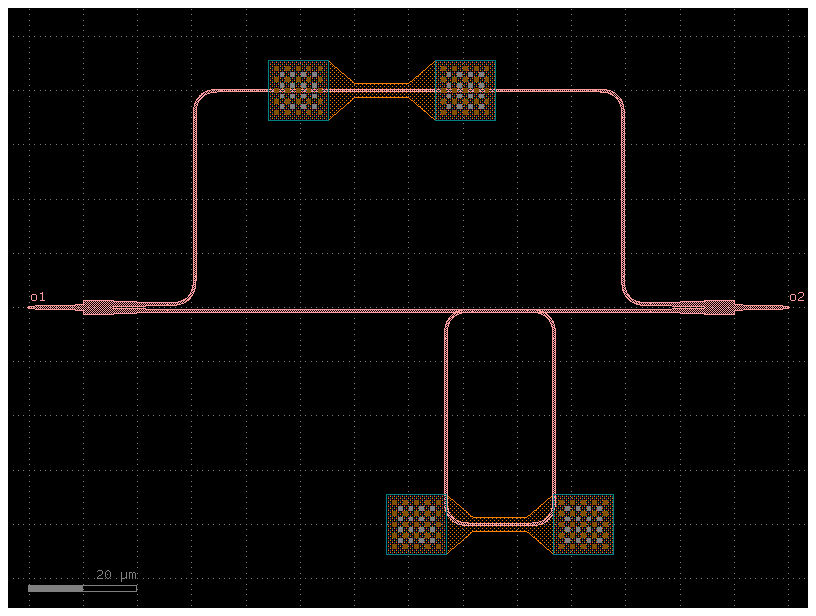

In [27]:
import gdsfactory as gf

c = gf.Component()

splitter = c.add_ref(gf.components.mmi1x2())
splitter.move((0, 0))

phase_shifter1 = c.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter1.move((50, 40))

phase_shifter2 = c.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter2.mirror()
phase_shifter2.move((50, -40))

combiner = c.add_ref(gf.components.mmi1x2())
combiner.mirror()
combiner.move((100, 0))

route1 = gf.routing.route_single(
    c,
    port1=splitter.ports['o2'],
    port2=phase_shifter1.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    c,
    port1=splitter.ports['o3'],
    port2=phase_shifter2.ports['o1'],
    cross_section='strip',
    radius=5,
)

route3 = gf.routing.route_single(
    c,
    port1=combiner.ports['o2'],
    port2=phase_shifter1.ports['o2'],
    cross_section='strip',
    radius=5,
)

route4 = gf.routing.route_single(
    c,
    port1=combiner.ports['o3'],
    port2=phase_shifter2.ports['o2'],
    cross_section='strip',
    radius=5,
)

c.add_port('o1', port=splitter.ports['o1'])
c.add_port('o2', port=combiner.ports['o1'])

c.draw_ports()
c.plot()

# Mach-Zehnder Modulator

## Sample 2 - good

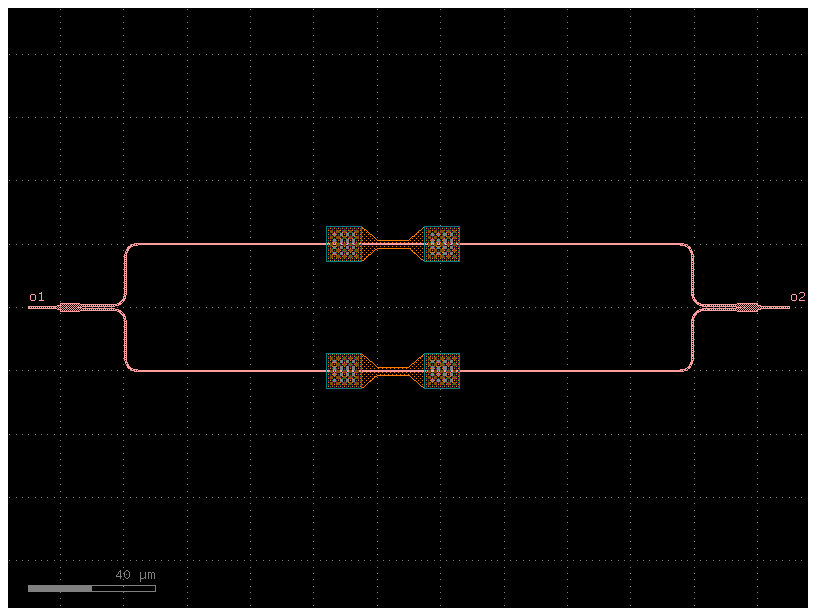

In [28]:
import gdsfactory as gf

c = gf.Component()

splitter = c << gf.components.mmi1x2()
combiner = c << gf.components.mmi1x2()
combiner.mirror()

phase_shifter1 = c << gf.components.straight_heater_metal(length=10)
phase_shifter2 = c << gf.components.straight_heater_metal(length=10)

splitter.move((0, 0))
phase_shifter1.move((100, 20))
phase_shifter2.move((100, -20))
combiner.move((200, 0))

route1 = gf.routing.route_single(
    c,
    port1=splitter.ports['o2'],
    port2=phase_shifter1.ports['o1'],
    cross_section='strip',
    radius=5
)

route2 = gf.routing.route_single(
    c,
    port1=splitter.ports['o3'],
    port2=phase_shifter2.ports['o1'],
    cross_section='strip',
    radius=5
)

route3 = gf.routing.route_single(
    c,
    port1=combiner.ports['o2'],
    port2=phase_shifter1.ports['o2'],
    cross_section='strip',
    radius=5
)

route4 = gf.routing.route_single(
    c,
    port1=combiner.ports['o3'],
    port2=phase_shifter2.ports['o2'],
    cross_section='strip',
    radius=5
)

c.add_port('o1', port=splitter.ports['o1'])
c.add_port('o2', port=combiner.ports['o1'])

c.draw_ports()
c.plot()

# Non-Linear Sign Gate

## Sample 0 - func

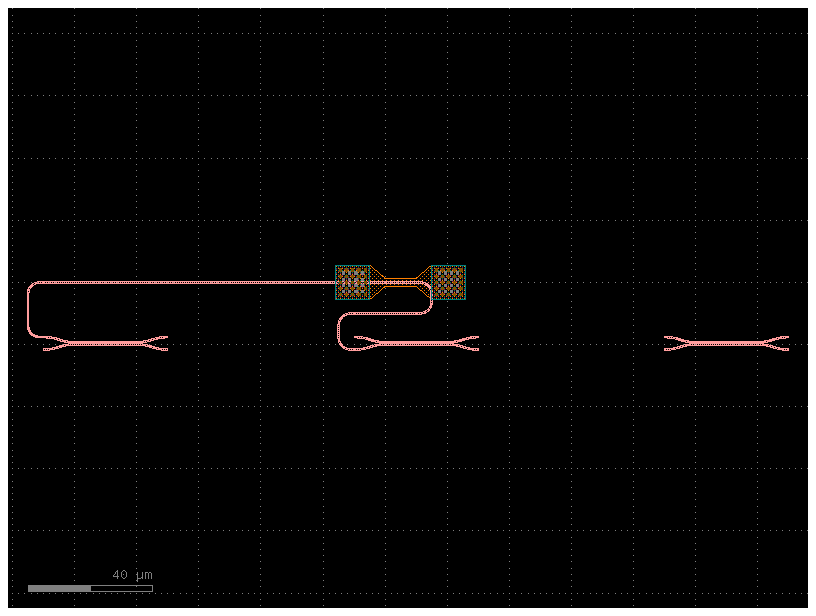

In [29]:
import gdsfactory as gf

c = gf.Component()

coupler1 = c.add_ref(gf.components.coupler())
coupler1.move((0, 0))

coupler2 = c.add_ref(gf.components.coupler())
coupler2.move((100, 0))

coupler3 = c.add_ref(gf.components.coupler())
coupler3.move((200, 0))

phase_shifter = c.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter.move((100, 20))

route1 = gf.routing.route_single(
    c,
    port1=coupler1.ports['o2'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    c,
    port1=phase_shifter.ports['o2'],
    port2=coupler2.ports['o1'],
    cross_section='strip',
    radius=5,
)

c.add_port('o1', port=coupler1.ports['o1'])
c.add_port('o2', port=coupler2.ports['o2'])
c.add_port('o3', port=coupler3.ports['o2'])

c.plot()

# Non-Linear Sign Gate

## Sample 1 - func

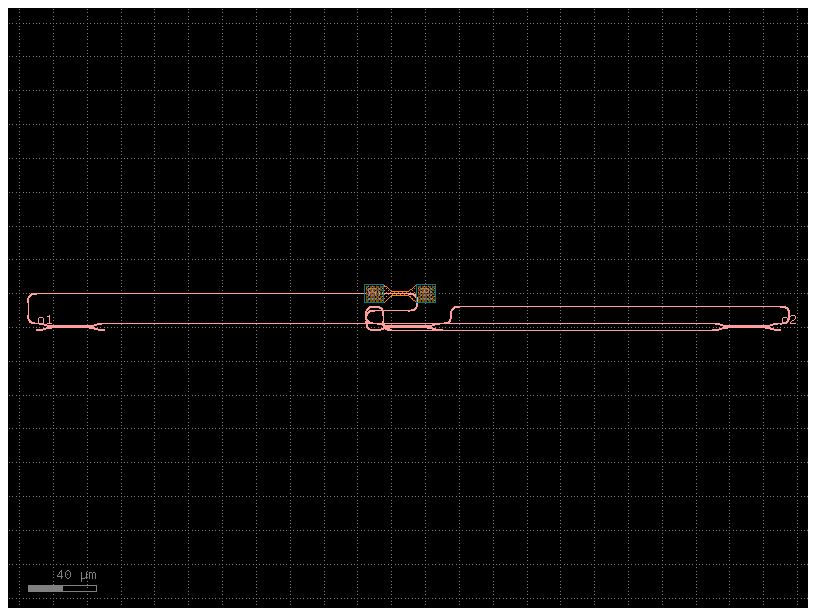

In [31]:
import gdsfactory as gf

c = gf.Component()

coupler1 = c.add_ref(gf.components.coupler())
coupler1.move((0, 0))

coupler2 = c.add_ref(gf.components.coupler())
coupler2.move((200, 0))

coupler3 = c.add_ref(gf.components.coupler())
coupler3.move((400, 0))

phase_shifter = c.add_ref(gf.components.straight_heater_metal(length=10))
phase_shifter.move((200, 20))

route1 = gf.routing.route_single(
    c,
    port1=coupler1.ports['o2'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    c,
    port1=phase_shifter.ports['o2'],
    port2=coupler2.ports['o1'],
    cross_section='strip',
    radius=5,
)

route3 = gf.routing.route_single(
    c,
    port1=coupler2.ports['o2'],
    port2=coupler3.ports['o1'],
    cross_section='strip',
    radius=5,
)

route4 = gf.routing.route_single(
    c,
    port1=coupler1.ports['o3'],
    port2=coupler3.ports['o2'],
    cross_section='strip',
    radius=5,
)

route5 = gf.routing.route_single(
    c,
    port1=coupler2.ports['o3'],
    port2=coupler3.ports['o3'],
    cross_section='strip',
    radius=5,
)

c.add_port('o1', port=coupler1.ports['o1'])
c.add_port('o2', port=coupler3.ports['o4'])

c.draw_ports()
c.plot()

# Non-Linear Sign Gate

## Sample 2 - func

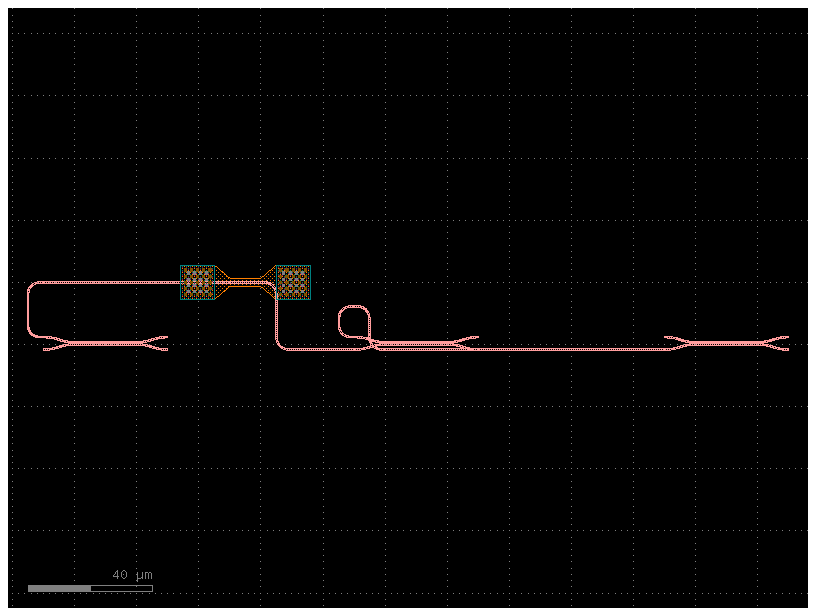

In [32]:
import gdsfactory as gf

c = gf.Component()

coupler1 = c.add_ref(gf.components.coupler())
coupler2 = c.add_ref(gf.components.coupler())
coupler3 = c.add_ref(gf.components.coupler())
phase_shifter = c.add_ref(gf.components.straight_heater_metal(length=10))

coupler1.move((0, 0))
coupler2.move((100, 0))
coupler3.move((200, 0))
phase_shifter.move((50, 20))

route1 = gf.routing.route_single(
    c,
    port1=coupler1.ports['o2'],
    port2=phase_shifter.ports['o1'],
    cross_section='strip',
    radius=5,
)

route2 = gf.routing.route_single(
    c,
    port1=phase_shifter.ports['o2'],
    port2=coupler2.ports['o1'],
    cross_section='strip',
    radius=5,
)

route3 = gf.routing.route_single(
    c,
    port1=coupler2.ports['o2'],
    port2=coupler3.ports['o1'],
    cross_section='strip',
    radius=5,
)

c.add_port('o1', port=coupler1.ports['o1'])
c.add_port('o2', port=coupler3.ports['o2'])
c.add_port('o3', port=coupler3.ports['o3'])
c.plot()